# 0050 KF-EnbPI：Baseline MSE 與 Peak-Weighted MSE 配對比較

這份實驗保留原本的 `KF_0050EnbPI.ipynb`。兩個版本使用同一份 0050 還原權值收盤價、相同 log 轉換、KF 分解、ARIMA、EnbPI、train/test 日期與 random seed；唯一差異是高頻 ANN 訓練時，Peak-Weighted 版本把高頻 target 中絕對偏離中位數最大的 10% 樣本給予 3 倍 MSE 權重。

因此比較表中的差異可以解讀為 peak weighting 的效果，而不是資料或分解不同造成的結果。

In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from kf_forecasting.models import kf_enbpi, kf_peak_weighted_enbpi
importlib.reload(kf_enbpi)
importlib.reload(kf_peak_weighted_enbpi)

from kf_forecasting.models.kf_enbpi import EnbPIConfig, run_kf_enbpi
from kf_forecasting.models.kf_peak_weighted_enbpi import (
    PeakWeightedEnbPIConfig,
    high_peak_metrics,
    run_peak_weighted_kf_enbpi,
)

np.random.seed(42)
pd.set_option('display.precision', 4)
print(f'Baseline module: {kf_enbpi.__file__}')
print(f'Weighted module: {kf_peak_weighted_enbpi.__file__}')

Baseline module: C:\Users\User\Desktop\程式\project\meeting\src\kf_forecasting\models\kf_enbpi.py
Weighted module: C:\Users\User\Desktop\程式\project\meeting\src\kf_forecasting\models\kf_peak_weighted_enbpi.py


In [8]:
def load_0050_actual_data(
    ticker='0050.TW',
    train_start='2022-01-01',
    train_end='2025-06-30',
    test_start='2025-07-01',
    test_end='2026-06-30',
):
    download_end = (pd.Timestamp(test_end) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    raw = yf.download(
        ticker, start=train_start, end=download_end,
        auto_adjust=True, progress=False,
    )
    if raw.empty:
        raise ValueError(f'No market data downloaded for {ticker}.')

    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close = close.dropna().astype(float)

    train_close = close.loc[train_start:train_end]
    test_close = close.loc[test_start:test_end]
    if train_close.empty or test_close.empty:
        raise ValueError('The selected train or test period has no observations.')

    full_close = pd.concat([train_close, test_close])
    if (full_close <= 0).any():
        raise ValueError('Log-price modeling requires strictly positive prices.')
    return {
        'ticker': ticker,
        'train_period': f'{train_start} to {train_end}',
        'test_period': f'{test_start} to {test_end}',
        'full_dates': pd.to_datetime(full_close.index),
        'test_dates': pd.to_datetime(test_close.index),
        'full_series': np.log(full_close).to_numpy(dtype=float),
        'train_series': np.log(train_close).to_numpy(dtype=float),
        'test_series': np.log(test_close).to_numpy(dtype=float),
        'full_price_series': full_close.to_numpy(dtype=float),
        'test_price_series': test_close.to_numpy(dtype=float),
    }

In [14]:
common_config = dict(
    window_size=4,
    alpha=0.05,
    n_bootstrap=30,
    block_length=None,
    batch_size=1,
    beta_grid_size=101,
    oob_bias_correction=True,
    oob_bias_correction_mode='combined',
    arima_order=None,
    arima_max_p=4,
    arima_max_q=4,
    ann_hidden_layers=(32, 10),
    ann_max_iter=500,
    ann_alpha=1e-4,
    ann_learning_rate_init=5e-4,
    ann_target_standardization=True,
    ann_early_stopping=False,
    ann_rolling_validation=True,
    ann_rolling_splits=3,
    ann_validation_fraction=0.10,
    ann_iteration_candidates=(125, 250, 500),
    ann_tol=1e-3,
    random_state=1234,
    process_variance=0.05,
    measurement_variance=10.0,
)

baseline_config = EnbPIConfig(**common_config)
weighted_config = PeakWeightedEnbPIConfig(
    **common_config,
    ann_peak_quantile=0.90,
    ann_peak_weight=5.0,
)

market_data = load_0050_actual_data()
observed_log = market_data['full_series']
train_size = len(market_data['train_series'])
horizon = len(market_data['test_series'])

print(f"Ticker       : {market_data['ticker']}")
print(f"Train period : {market_data['train_period']} ({train_size} points)")
print(f"Test period  : {market_data['test_period']} ({horizon} points)")
print(f"Seeds        : numpy=42, bootstrap/ANN={baseline_config.random_state}")
print(f"Peak rule    : top {100 * (1 - weighted_config.ann_peak_quantile):.0f}% gets {weighted_config.ann_peak_weight:.1f}x MSE weight")

Ticker       : 0050.TW
Train period : 2022-01-01 to 2025-06-30 (843 points)
Test period  : 2025-07-01 to 2026-06-30 (243 points)
Seeds        : numpy=42, bootstrap/ANN=1234
Peak rule    : top 10% gets 5.0x MSE weight


In [15]:
baseline_result = run_kf_enbpi(
    observed_log,
    train_size,
    config=baseline_config,
    model_name='0050_baseline_mse',
)
weighted_result = run_peak_weighted_kf_enbpi(
    observed_log,
    train_size,
    config=weighted_config,
    model_name='0050_peak_weighted_mse',
)

assert np.allclose(baseline_result.estimated_low, weighted_result.estimated_low)
assert np.allclose(baseline_result.estimated_high, weighted_result.estimated_high)
print('Paired run complete: the two versions used identical KF low/high references.')

c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\User\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

Paired run complete: the two versions used identical KF low/high references.


In [16]:
def transformed_price_metrics(result):
    truth = market_data['test_price_series']
    point = np.exp(result.point)
    lower = np.exp(result.lower)
    upper = np.exp(result.upper)
    error = truth - point
    return {
        'rmse': float(np.sqrt(np.mean(error ** 2))),
        'coverage': float(np.mean((truth >= lower) & (truth <= upper))),
        'mean_width': float(np.mean(upper - lower)),
        'bias_truth_minus_prediction': float(np.mean(error)),
    }

baseline_log = baseline_result.metrics()
weighted_log = weighted_result.metrics()
baseline_price = transformed_price_metrics(baseline_result)
weighted_price = transformed_price_metrics(weighted_result)
baseline_peak = high_peak_metrics(
    baseline_result, peak_quantile=weighted_config.ann_peak_quantile
)
weighted_peak = high_peak_metrics(
    weighted_result, peak_quantile=weighted_config.ann_peak_quantile
)

comparison_specs = [
    ('final_price_rmse', baseline_price['rmse'], weighted_price['rmse'], 'lower'),
    ('final_price_coverage', baseline_price['coverage'], weighted_price['coverage'], 'target_0.95'),
    ('final_price_mean_width', baseline_price['mean_width'], weighted_price['mean_width'], 'report_only'),
    ('final_price_bias_truth_minus_prediction', baseline_price['bias_truth_minus_prediction'], weighted_price['bias_truth_minus_prediction'], 'closer_to_0'),
    ('final_log_rmse', baseline_log['rmse'], weighted_log['rmse'], 'lower'),
    ('high_kf_rmse', baseline_log['high_kf_rmse'], weighted_log['high_kf_rmse'], 'lower'),
    ('high_tail_rmse', baseline_peak['kf_high_tail_rmse'], weighted_peak['kf_high_tail_rmse'], 'lower'),
    ('high_regular_rmse', baseline_peak['kf_high_regular_rmse'], weighted_peak['kf_high_regular_rmse'], 'lower'),
    ('high_peak_recall', baseline_peak['kf_high_peak_recall'], weighted_peak['kf_high_peak_recall'], 'higher'),
    ('high_peak_sign_accuracy', baseline_peak['kf_high_peak_sign_accuracy'], weighted_peak['kf_high_peak_sign_accuracy'], 'higher'),
    ('high_peak_amplitude_ratio', baseline_peak['kf_high_peak_amplitude_ratio'], weighted_peak['kf_high_peak_amplitude_ratio'], 'closer_to_1'),
    ('high_enbpi_coverage', baseline_log['high_enbpi_coverage'], weighted_log['high_enbpi_coverage'], 'target_0.95'),
    ('high_enbpi_mean_width', baseline_log['high_enbpi_mean_width'], weighted_log['high_enbpi_mean_width'], 'report_only'),
]

def improvement_value(baseline, weighted, rule):
    if rule == 'lower':
        return baseline - weighted
    if rule == 'higher':
        return weighted - baseline
    if rule == 'closer_to_0':
        return abs(baseline) - abs(weighted)
    if rule == 'closer_to_1':
        return abs(baseline - 1.0) - abs(weighted - 1.0)
    if rule == 'target_0.95':
        return abs(baseline - 0.95) - abs(weighted - 0.95)
    return np.nan

comparison = pd.DataFrame([
    {
        'metric': name,
        'baseline': baseline,
        'peak_weighted': weighted,
        'weighted_minus_baseline': weighted - baseline,
        'improvement_positive_is_better': improvement_value(baseline, weighted, rule),
        'criterion': rule,
    }
    for name, baseline, weighted, rule in comparison_specs
])

config_summary = pd.DataFrame([
    {'item': 'train_period', 'value': market_data['train_period']},
    {'item': 'test_period', 'value': market_data['test_period']},
    {'item': 'train_points', 'value': train_size},
    {'item': 'test_points', 'value': horizon},
    {'item': 'ensemble_seed', 'value': baseline_config.random_state},
    {'item': 'peak_quantile', 'value': weighted_config.ann_peak_quantile},
    {'item': 'peak_weight', 'value': weighted_config.ann_peak_weight},
    {'item': 'baseline_arima_order', 'value': str(baseline_result.selected_arima_order)},
    {'item': 'weighted_arima_order', 'value': str(weighted_result.selected_arima_order)},
    {'item': 'baseline_elapsed_seconds', 'value': baseline_result.elapsed_seconds},
    {'item': 'weighted_elapsed_seconds', 'value': weighted_result.elapsed_seconds},
])

display(config_summary)
display(comparison)

,item,value
0,train_period,2022-01-01 to 2025-06-30
1,test_period,2025-07-01 to 2026-06-30
2,train_points,843
3,test_points,243
4,ensemble_seed,1234
5,peak_quantile,0.9
6,peak_weight,5.0
7,baseline_arima_order,"(2, 0, 0)"
8,weighted_arima_order,"(2, 0, 0)"
9,baseline_elapsed_seconds,54.1389


,metric,baseline,peak_weighted,weighted_minus_baseline,improvement_positive_is_better,criterion
0,final_price_rmse,1.5492,1.3754,-0.1738,0.1738,lower
1,final_price_coverage,0.8724,0.9136,0.0412,0.0412,target_0.95
2,final_price_mean_width,3.9710,3.9590,-0.0120,NaN,report_only
3,final_price_bias_truth_minus_prediction,0.6903,0.4014,-0.2889,0.2889,closer_to_0
4,final_log_rmse,0.0189,0.0169,-0.0020,0.0020,lower
5,high_kf_rmse,0.0186,0.0164,-0.0022,0.0022,lower
6,high_tail_rmse,0.0280,0.0235,-0.0044,0.0044,lower
7,high_regular_rmse,0.0172,0.0153,-0.0019,0.0019,lower
8,high_peak_recall,0.2400,0.3200,0.0800,0.0800,higher
9,high_peak_sign_accuracy,1.0000,1.0000,0.0000,0.0000,higher


In [17]:
test_dates = market_data['test_dates']
high_reference = baseline_result.estimated_high[baseline_result.test_times]
high_center = float(np.median(high_reference))
high_threshold = float(np.quantile(
    np.abs(high_reference - high_center), weighted_config.ann_peak_quantile
))
is_peak = np.abs(high_reference - high_center) >= high_threshold

peak_detail = pd.DataFrame({
    'date': test_dates[is_peak],
    'kf_high_reference': high_reference[is_peak],
    'baseline_high_prediction': baseline_result.high_point[is_peak],
    'weighted_high_prediction': weighted_result.high_point[is_peak],
    'baseline_abs_error': np.abs(high_reference[is_peak] - baseline_result.high_point[is_peak]),
    'weighted_abs_error': np.abs(high_reference[is_peak] - weighted_result.high_point[is_peak]),
})
peak_detail['weighted_error_gain'] = (
    peak_detail['baseline_abs_error'] - peak_detail['weighted_abs_error']
)
display(peak_detail.sort_values('weighted_error_gain', ascending=False))

,date,kf_high_reference,baseline_high_prediction,weighted_high_prediction,baseline_abs_error,weighted_abs_error,weighted_error_gain
23,2026-06-01,0.1060,0.0788,0.0926,0.0272,0.0134,0.0138
17,2026-05-05,0.1122,0.0877,0.0988,0.0245,0.0134,0.0111
14,2026-04-27,0.1337,0.0801,0.0910,0.0536,0.0427,0.0108
15,2026-04-28,0.1145,0.1008,0.1116,0.0137,0.0029,0.0108
19,2026-05-07,0.1267,0.0917,0.1025,0.0350,0.0242,0.0107
24,2026-06-03,0.1103,0.0795,0.0891,0.0308,0.0211,0.0097
20,2026-05-08,0.1114,0.0985,0.1081,0.0129,0.0033,0.0096
5,2026-02-25,0.1102,0.0744,0.0838,0.0358,0.0264,0.0094
6,2026-02-26,0.1032,0.0860,0.0942,0.0173,0.0090,0.0082
21,2026-05-11,0.1028,0.0921,0.0989,0.0107,0.0039,0.0068


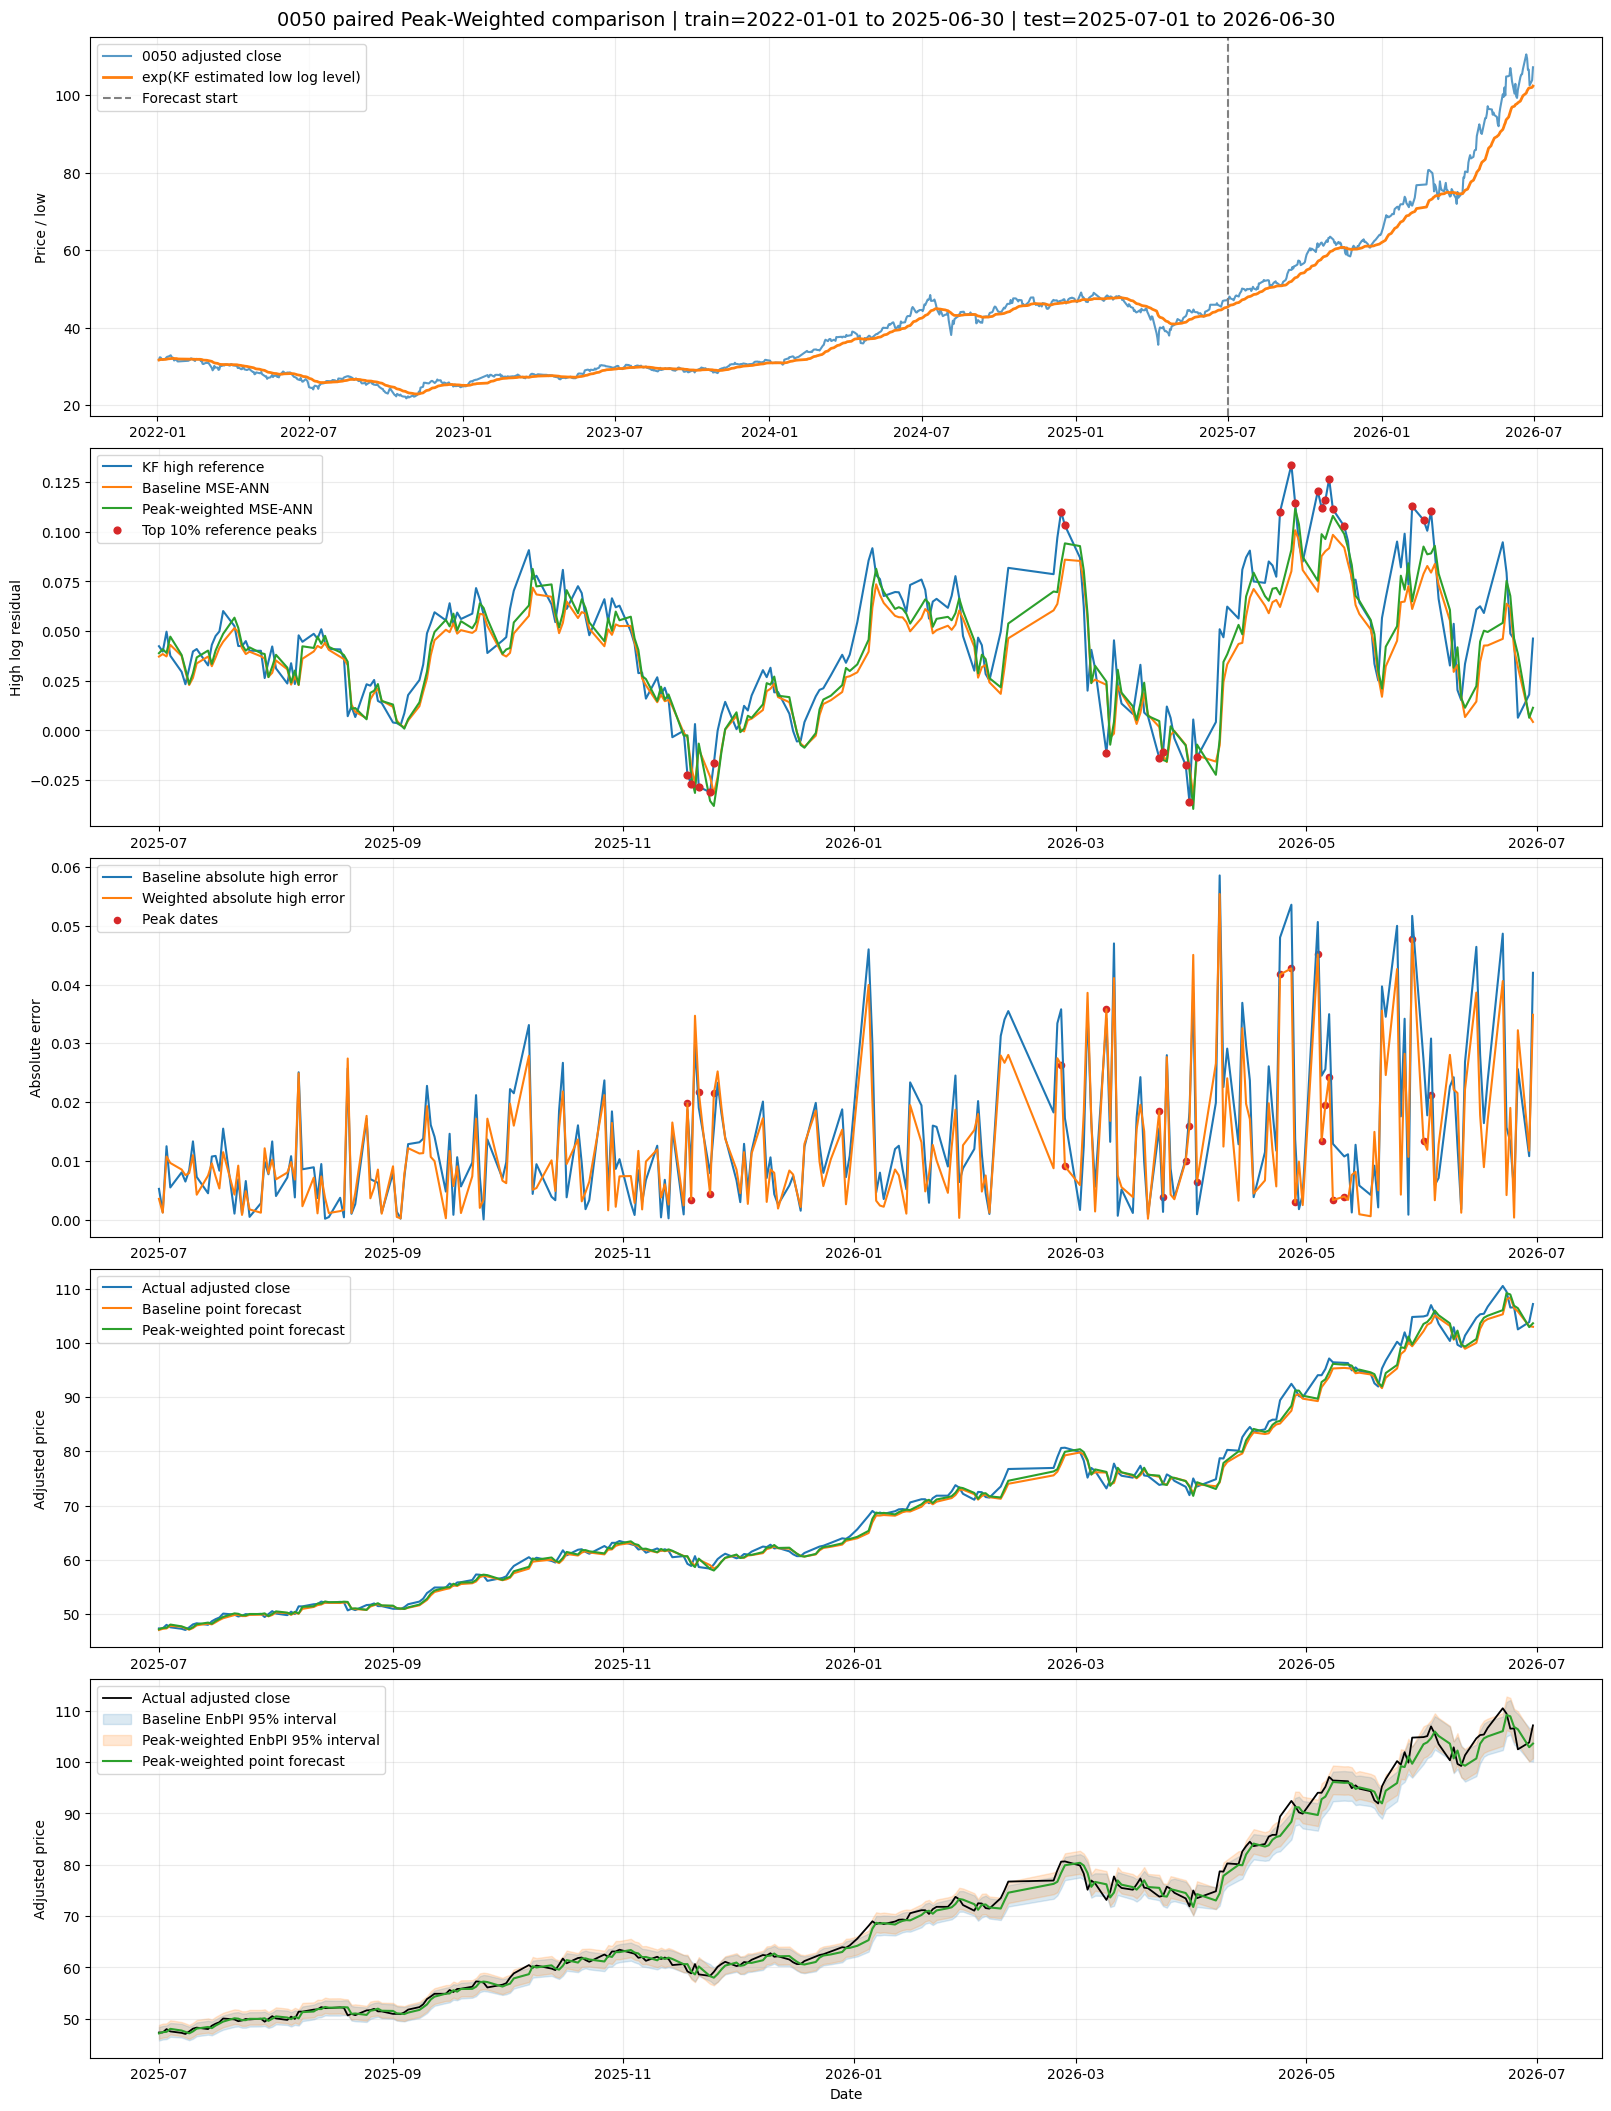

In [18]:
full_dates = market_data['full_dates']
price_truth = market_data['test_price_series']
baseline_price_point = np.exp(baseline_result.point)
weighted_price_point = np.exp(weighted_result.point)
baseline_price_lower = np.exp(baseline_result.lower)
baseline_price_upper = np.exp(baseline_result.upper)
weighted_price_lower = np.exp(weighted_result.lower)
weighted_price_upper = np.exp(weighted_result.upper)
forecast_start = test_dates[0]

fig, axes = plt.subplots(5, 1, figsize=(16, 21), constrained_layout=True)
fig.suptitle(
    f"0050 paired Peak-Weighted comparison | train={market_data['train_period']} | test={market_data['test_period']}",
    fontsize=14,
)

axes[0].plot(full_dates, market_data['full_price_series'], label='0050 adjusted close', alpha=0.75)
axes[0].plot(full_dates, np.exp(baseline_result.estimated_low), label='exp(KF estimated low log level)', linewidth=2)
axes[0].axvline(forecast_start, color='gray', linestyle='--', label='Forecast start')
axes[0].set_ylabel('Price / low')
axes[0].legend(loc='best')

axes[1].plot(test_dates, high_reference, label='KF high reference', color='tab:blue')
axes[1].plot(test_dates, baseline_result.high_point, label='Baseline MSE-ANN', color='tab:orange')
axes[1].plot(test_dates, weighted_result.high_point, label='Peak-weighted MSE-ANN', color='tab:green')
axes[1].scatter(test_dates[is_peak], high_reference[is_peak], color='tab:red', s=24, zorder=4, label='Top 10% reference peaks')
axes[1].set_ylabel('High log residual')
axes[1].legend(loc='best')

axes[2].plot(test_dates, np.abs(high_reference - baseline_result.high_point), label='Baseline absolute high error')
axes[2].plot(test_dates, np.abs(high_reference - weighted_result.high_point), label='Weighted absolute high error')
axes[2].scatter(test_dates[is_peak], np.abs(high_reference[is_peak] - weighted_result.high_point[is_peak]), color='tab:red', s=20, label='Peak dates')
axes[2].set_ylabel('Absolute error')
axes[2].legend(loc='best')

axes[3].plot(test_dates, price_truth, label='Actual adjusted close', color='tab:blue')
axes[3].plot(test_dates, baseline_price_point, label='Baseline point forecast', color='tab:orange')
axes[3].plot(test_dates, weighted_price_point, label='Peak-weighted point forecast', color='tab:green')
axes[3].set_ylabel('Adjusted price')
axes[3].legend(loc='best')

axes[4].plot(test_dates, price_truth, label='Actual adjusted close', color='black', linewidth=1.3)
axes[4].fill_between(test_dates, baseline_price_lower, baseline_price_upper, color='tab:blue', alpha=0.16, label='Baseline EnbPI 95% interval')
axes[4].fill_between(test_dates, weighted_price_lower, weighted_price_upper, color='tab:orange', alpha=0.18, label='Peak-weighted EnbPI 95% interval')
axes[4].plot(test_dates, weighted_price_point, color='tab:green', label='Peak-weighted point forecast')
axes[4].set_ylabel('Adjusted price')
axes[4].set_xlabel('Date')
axes[4].legend(loc='best')

for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

## 如何判斷有沒有幫助

先看 `high_tail_rmse`：`improvement_positive_is_better > 0` 表示 peak-weighted ANN 在最大的 10% KF-high 上誤差較小。接著看 `high_peak_recall` 與 `high_peak_amplitude_ratio`，前者越高代表抓到更多尖峰，後者越接近 1 代表預測振幅越接近參考高頻。最後確認 `final_price_rmse` 沒有明顯惡化，而且涵蓋率仍接近 0.95。

0050 只有一條實際路徑，因此單次結果只能當案例比較；若要做較可靠的結論，下一步應固定日期，改用多組 ensemble seeds 或 rolling-origin test periods 做配對比較。